In [ ]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()
engine = create_engine(os.getenv("SUPABASE_DB_URL"))

def load_cleaned():
    return pd.read_sql("SELECT * FROM telco_customer.stg_churn_cleaned", engine)

# 1. Load the data cleaned in the EDA
df = load_cleaned()

# Filter for the high-risk segment identified in modeling
m2m_df = df[df['contract'] == 'Month-to-month'].copy()

/var/folders/bg/bg6_lhk10cb2v0n9434vjxb80000gn/T/ipykernel_15185/974307121.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lifecycle_risk = m2m_df.groupby('lifecycle_stage').agg(
/var/folders/bg/bg6_lhk10cb2v0n9434vjxb80000gn/T/ipykernel_15185/974307121.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=lifecycle_risk, x='lifecycle_stage', y='churn', palette='Reds_r')


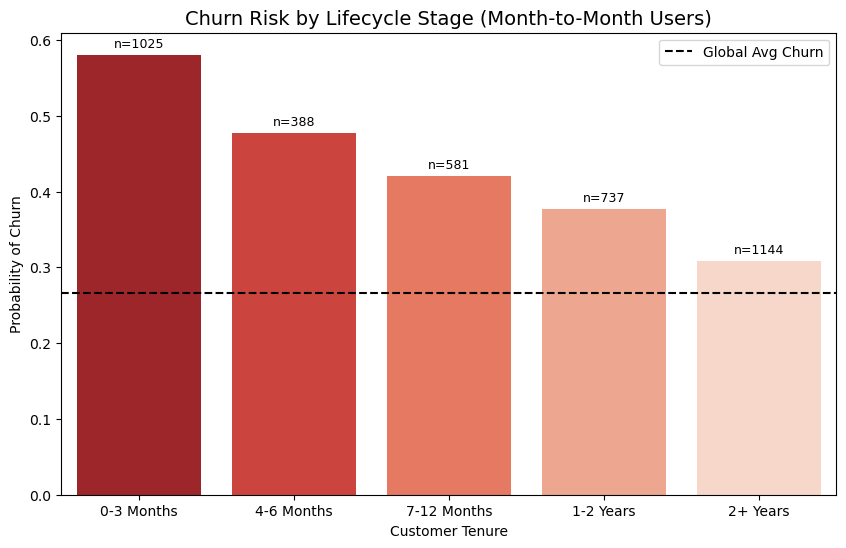

In [15]:
# 1. Create lifecycle buckets
bins = [0, 3, 6, 12, 24, 72]
labels = ['0-3 Months', '4-6 Months', '7-12 Months', '1-2 Years', '2+ Years']
m2m_df['lifecycle_stage'] = pd.cut(m2m_df['tenure'], bins=bins, labels=labels)

# 2. Calculate churn rate AND sample size per stage
lifecycle_risk = m2m_df.groupby('lifecycle_stage').agg(
    churn=('churn', 'mean'),
    n=('churn', 'count')
).reset_index()

# 3. Visualize the "Danger Zone"
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=lifecycle_risk, x='lifecycle_stage', y='churn', palette='Reds_r')
plt.title('Churn Risk by Lifecycle Stage (Month-to-Month Users)', fontsize=14)
plt.ylabel('Probability of Churn')
plt.xlabel('Customer Tenure')
plt.axhline(df['churn'].mean(), color='black', linestyle='--', label='Global Avg Churn')

# Add n= annotations so extreme rates are seen in context
for i, row in lifecycle_risk.iterrows():
    ax.text(i, row['churn'] + 0.01, f'n={row["n"]}', ha='center', fontsize=9, color='black')

plt.legend()
plt.show()

/var/folders/bg/bg6_lhk10cb2v0n9434vjxb80000gn/T/ipykernel_15185/3454177863.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  internet_lifecycle = m2m_df.groupby(['lifecycle_stage', 'internet_service'])['churn'].mean().unstack()


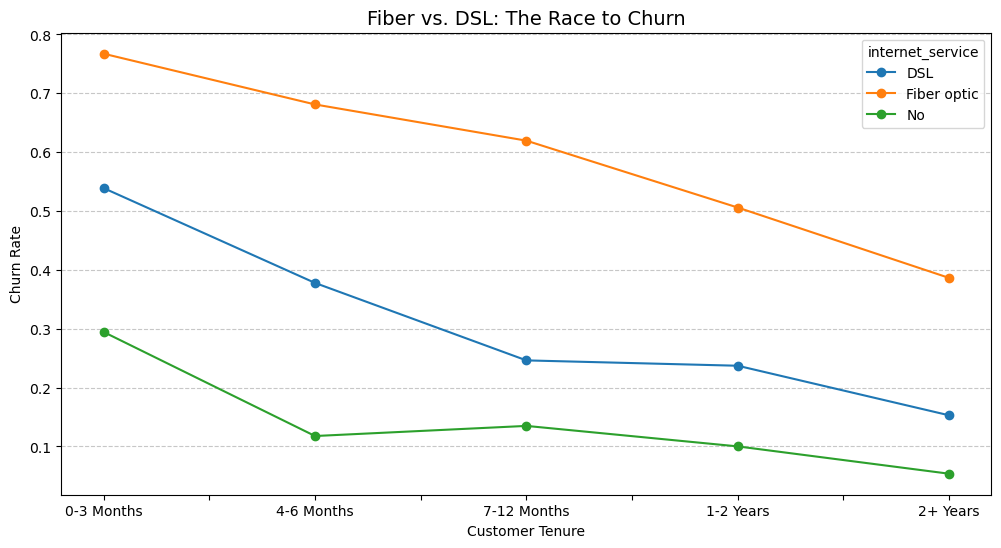

In [16]:
# Compare churn rates across tenure for different internet types
internet_lifecycle = m2m_df.groupby(['lifecycle_stage', 'internet_service'])['churn'].mean().unstack()

internet_lifecycle.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Fiber vs. DSL: The Race to Churn', fontsize=14)
plt.ylabel('Churn Rate')
plt.xlabel('Customer Tenure') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

While price increases are a known risk at the 12-month mark, our lifecycle analysis proves that onboarding friction is the primary threat for Fiber Optic users. With an 80% churn rate in the first 3 months, the business is losing the majority of its high-value customers before they even pay their fourth bill. Our model's identification of Fiber Optic (Weight: 0.978) as a churn driver is largely fueled by this early-life volatility.

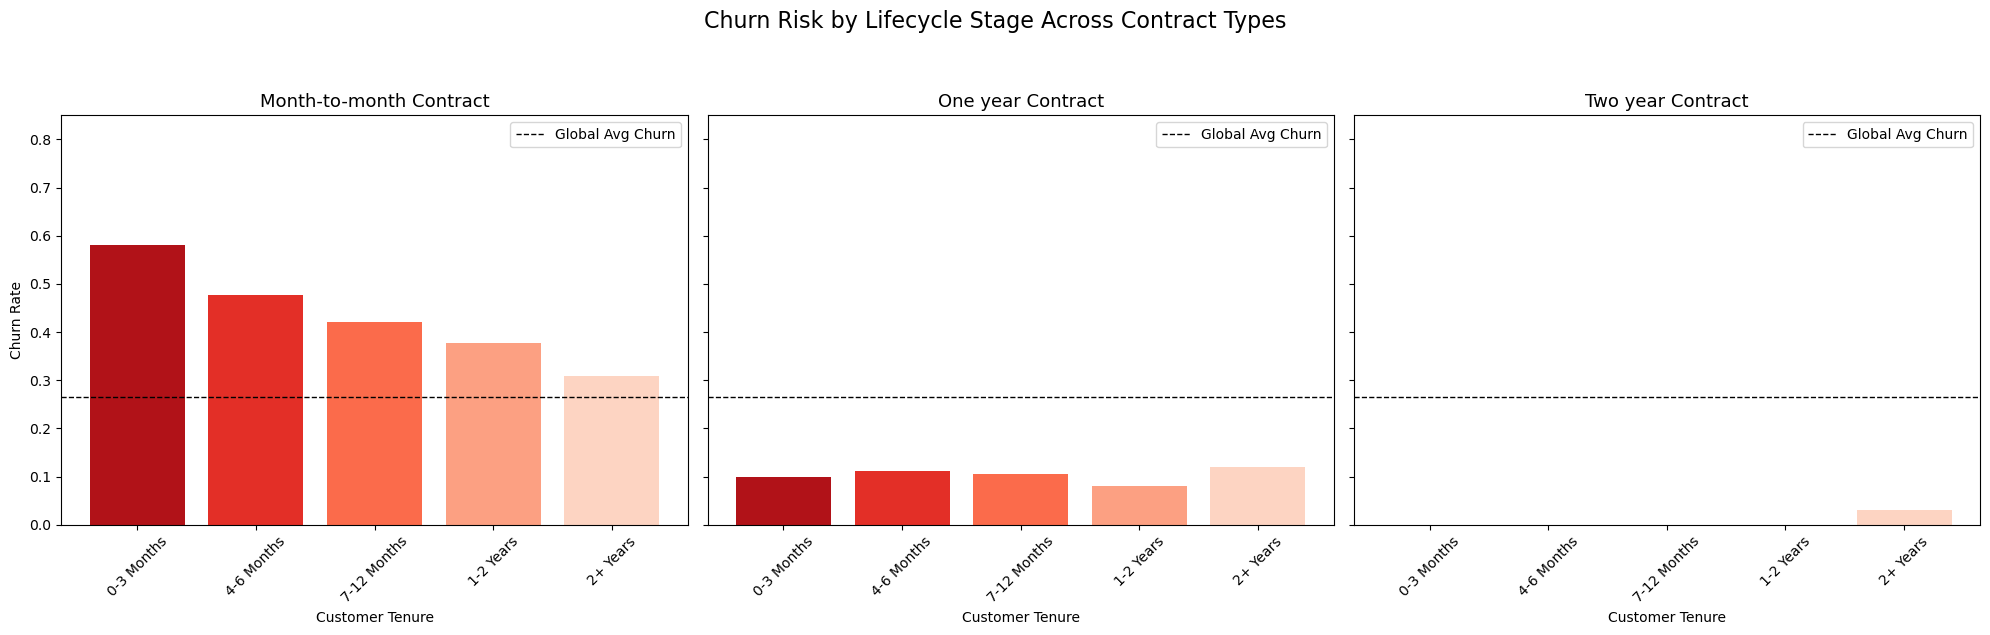

In [13]:
# Compare churn risk across the three contract types in parallel
contracts = ['Month-to-month', 'One year', 'Two year']
bins = [0, 3, 6, 12, 24, 72]
labels = ['0-3 Months', '4-6 Months', '7-12 Months', '1-2 Years', '2+ Years']
bar_colors = sns.color_palette('Reds_r', n_colors=len(labels))

global_avg_churn = df['churn'].mean()
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, contract in zip(axes, contracts):
    contract_df = df[df['contract'] == contract].copy()

    if contract_df.empty:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{contract} Contract', fontsize=13)
        ax.set_xlabel('Customer Tenure')
        ax.set_ylabel('Churn Rate' if ax is axes[0] else '')
        ax.axhline(global_avg_churn, color='black', linestyle='--', linewidth=1, label='Global Avg Churn')
        ax.legend(loc='upper right')
        continue

    contract_df['lifecycle_stage'] = pd.cut(
        contract_df['tenure'],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    contract_df['churn_numeric'] = contract_df['churn'].astype(float)

    lifecycle_risk = (
        contract_df.groupby('lifecycle_stage', observed=True)['churn_numeric']
        .mean()
        .reindex(labels)
        .fillna(0)
    )

    ax.bar(lifecycle_risk.index.astype(str), lifecycle_risk.values, color=bar_colors)
    ax.set_title(f'{contract} Contract', fontsize=13)
    ax.set_xlabel('Customer Tenure')
    ax.set_ylabel('Churn Rate' if ax is axes[0] else '')
    ax.axhline(global_avg_churn, color='black', linestyle='--', linewidth=1, label='Global Avg Churn')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 0.85)
    ax.legend(loc='upper right')

plt.suptitle('Churn Risk by Lifecycle Stage Across Contract Types', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

/var/folders/bg/bg6_lhk10cb2v0n9434vjxb80000gn/T/ipykernel_15185/1542201099.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=late_churn, x='contract', y='churn_rate', palette='Reds_r')


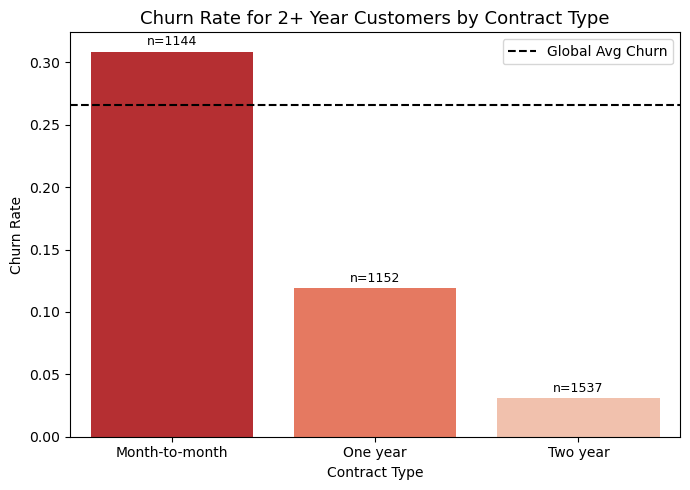

In [17]:
# Late-stage churn (2+ years) across contract types — backing the 'Technology Refresh' hypothesis
late_stage = df[df['tenure'] > 24].copy()
late_churn = late_stage.groupby('contract').agg(
    churn_rate=('churn', 'mean'),
    n=('churn', 'count')
).reset_index()

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=late_churn, x='contract', y='churn_rate', palette='Reds_r')
plt.axhline(df['churn'].mean(), color='black', linestyle='--', label='Global Avg Churn')
for i, row in late_churn.iterrows():
    ax.text(i, row['churn_rate'] + 0.005, f'n={row["n"]}', ha='center', fontsize=9)
plt.title('Churn Rate for 2+ Year Customers by Contract Type', fontsize=13)
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.legend()
plt.tight_layout()
plt.show()

# Even loyal long-tenure customers show elevated churn risk — particularly on month-to-month.
# Proactive hardware/pricing review at Month 24 is the recommended intervention.

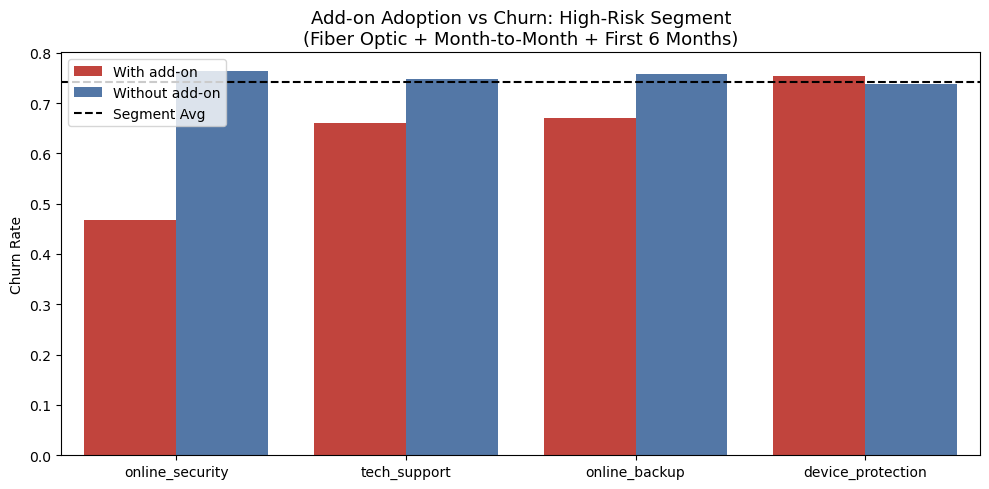

In [18]:
# Add-on adoption vs churn within the highest-risk segment (Fiber + M2M + first 6 months)
high_risk = df[
    (df['contract'] == 'Month-to-month') &
    (df['internet_service'] == 'Fiber optic') &
    (df['tenure'] <= 6)
].copy()

addons = ['online_security', 'tech_support', 'online_backup', 'device_protection']
addon_churn = {}
for col in addons:
    rates = high_risk.groupby(col)['churn'].mean()
    if 'Yes' in rates.index and 'No' in rates.index:
        addon_churn[col] = {'With add-on': rates['Yes'], 'Without add-on': rates['No']}

addon_df = pd.DataFrame(addon_churn).T.reset_index()
addon_df.columns = ['Add-on', 'With add-on', 'Without add-on']
addon_df = addon_df.melt(id_vars='Add-on', var_name='Status', value_name='Churn Rate')

plt.figure(figsize=(10, 5))
sns.barplot(data=addon_df, x='Add-on', y='Churn Rate', hue='Status', palette=['#d73027', '#4575b4'])
plt.title('Add-on Adoption vs Churn: High-Risk Segment\n(Fiber Optic + Month-to-Month + First 6 Months)', fontsize=13)
plt.ylabel('Churn Rate')
plt.xlabel('')
plt.axhline(high_risk['churn'].mean(), color='black', linestyle='--', label='Segment Avg')
plt.legend()
plt.tight_layout()
plt.show()

# If add-on adoption correlates with lower churn even in the highest-risk segment,
# bundling tech_support or online_security into Fiber onboarding is a concrete retention lever.

I hypothesized that One-Year customers would churn at Month 13 due to price increases; however, the data reveals a 'Loyalty Dip' at that stage. This suggests our one-year contract is a massive success at 'training' customers into the service.

The real immediate business threat is the extreme volatility of Fiber Optic users in their first 90 days, where churn rates hit nearly 80%, though this should be validated as sample sizes in the 0–3 month bucket are limited. However, we also observe a significant rise in churn after the 2-year mark across all contract types.

This suggests the one-year contract's renewal moment is relatively safe, and retention budget currently allocated to Month-12 interventions may be better redeployed toward early-lifecycle Fiber customers.

For future analysis and action, I recommend:

- A 'Technology Refresh' Audit: Investigate if 2+ year customers are on legacy pricing or outdated hardware. We should test if proactive equipment upgrades at Month 24 can preempt this late-stage churn.

- The 'First 90 Days' Task Force: Shift retention budget away from 12-month renewals and toward the Fiber Optic onboarding experience. Identifying the 'moment of friction' in the first 3 months is the single highest-leverage opportunity for revenue protection.

- An 'Onboarding Bundle' Test: If add-on adoption (TechSupport, OnlineSecurity) correlates with lower churn in the first 6 months, bundling these into Fiber onboarding packages — even at a discount — may be the lowest-cost retention lever available.